# Tarea 0 - Setup & First Contact with All Three Datasets - IELE756


*   **Team members**: Jose Pino y Javier Becerra 
*   **Region**: XIV - Los Rios
*   **Date**: 12-03-2026

* **Contexto:** En el presente notebook se encuentra el desarrollo de la tarea investigativa introductoria del ramo Preparación y Analisis de datos, el cual tiene como nombre "IELE756T". En esta tarea se analizará 3 dataset los cuales son: Censo 2024, ENO y GRD. 

---
## Parte 1: Censo 2024 (1,5 pts)

### 1.1. Cargar el Censo

In [2]:
import pandas as pd #importamos la librería pandas para trabajar con DataFrames
persona = pd.read_parquet( #leemos el archivo parquet con las columnas especificadas
"personas_censo2024.parquet", #nombre del archivo
columns=["region", "comuna", "sexo", "edad", #columnas seleccionadas
"p27_nacionalidad", "p27_nacionalidad_rec", # nacionalidad y nacionalidad reconocida
"escolaridad", "sit_fuerza_trabajo"], # escolaridad y situación en la fuerza de trabajo
)
print(f"Total personas: {len(persona):,}") #cantidad total de personas en el DataFrame
print(persona.dtypes) #tipos de datos de cada columna

Total personas: 18,480,432
region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object


Se ha leído correctamente el archivo parquet

### 1.2. Inspeccionar

In [3]:
# 1. ¿Cuántas filas y columnas tiene?
print("--- Dimensiones (Filas, Columnas) ---")
print(persona.shape)

print("\n--- Tipos de datos de las columnas ---")
# 2. ¿Qué tipos de datos son? (int, float, object, etc.)
print(persona.dtypes)

print("\n--- Primeras 10 filas del dataset ---")
# 3. Mostrar las primeras 10 filas
persona.head(10)

--- Dimensiones (Filas, Columnas) ---
(18480432, 8)

--- Tipos de datos de las columnas ---
region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

--- Primeras 10 filas del dataset ---


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [4]:
persona.info() # información general del DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


### 1.3. Filtrar a Los Ríos

In [5]:
#region es numérico en el Censo
los_rios= persona[persona["region"]== 14] #filtramos por la región de Los Ríos, que es la número 14
print(f"Los Ríos:{len(los_rios):,} personas") #cantidad de personas en Los Ríos

Los Ríos:398,230 personas


### 1.4. Nacionalidad

Investigamos la nacionalidad con las columnas ```"p27_nacionalidad"``` y ```"p27_nacionalidad_rec"``` y se encuentra que la mayoría de las personas en Los Ríos son de nacionalidad chilena, con un total de 382.383 personas. Además, hay una cantidad significativa de personas con nacionalidad desconocida, con un total de 1.717 personas.

In [6]:
# Códigos: 1=Chileno,2=Chileno+otra, 3=Extranjero,-99=NR
print(los_rios["p27_nacionalidad"].value_counts()) #cantidad de personas por cada categoría de nacionalidad en Los Ríos

p27_nacionalidad
 1     382383
 3       5502
-66      5501
 2       3127
-99      1717
Name: count, dtype: int64


In [7]:
#Variable recodificada (más conveniente)
print(los_rios["p27_nacionalidad_rec"].value_counts()) #cantidad de personas por cada categoría de nacionalidad reconocida en Los Ríos
foreign = los_rios["p27_nacionalidad_rec"]\
.value_counts(normalize=True) #proporción de cada categoría de nacionalidad reconocida en Los Ríos
print(f"%extranjeros:{foreign.get(2, 0):.1%}") #porcentaje de extranjeros en Los Ríos, usando get para evitar error si no hay extranjeros 

p27_nacionalidad_rec
 1     390968
 2       5531
-99      1731
Name: count, dtype: int64
%extranjeros:1.4%


---
## Parte 2: ENO - Enfermedades de Notificación Obligatoria

### 2.1. Cargar ENO
Cargamos la base y la observamos:

In [8]:
import warnings
warnings.filterwarnings("ignore") #ignorar advertencias para una salida más limpia
eno= pd.read_csv( #leemos el archivo csv con los datos de ENO
"20241218_base_eno_final.csv", #nombre del archivo
sep=";",encoding="utf-8-sig") #separador y codificación para leer el csv correctamente
print(f"Total:{len(eno):,}") #cantidad total de filas en el DataFrame de ENO
print(eno.columns.tolist()) #lista de nombres de columnas en el DataFrame de ENO

Total:333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


In [9]:
# Ver valores unicos de la región en ENO
print(eno["region"].unique()) #valores únicos de la columna región en ENO

<ArrowStringArray>
[                                 'Región de Tarapacá',
                                'Región de Valparaíso',
                    'Región Metropolitana de Santiago',
                                 'Región de Los Lagos',
                        'Región de Arica y Parinacota',
                                   'Región del Biobío',
                                  'Región de Los Ríos',
                               'Región de Antofagasta',
                              'Región de la Araucanía',
     'Región del Libertador General Bernardo OHiggins',
 'Región de Aysén del General Carlos Ibáñez del Campo',
                                    'Región del Ñuble',
                                    'Región del Maule',
                                   'Región de Atacama',
                                  'Región de Coquimbo',
         'Región de Magallanes y la Antártica Chilena',
                                         'Desconocido']
Length: 17, dtype: str


### 2.2. Filtrar ENO a Los Ríos

Se filtra por la región de los rios quedando un total de 5.502 casos.

In [10]:
eno_lr=eno[eno["region"]== "Región de Los Ríos"] #filtramos por la región de Los Ríos en ENO
print(f"Los Ríos:{len(eno_lr):,}")

Los Ríos:5,581


### 2.3. Distribución de casos por año de notificación

Se explora la distribución de casos por año de notificación en Los Ríos utilizando el método ```.value_counts()``` sobre la columna ```"año_notificacion"``` del DataFrame eno_lr. Esto nos permite identificar si hay algún año con un número significativamente mayor o menor de casos reportados, lo cual podría indicar tendencias o eventos específicos relacionados con las enfermedades de notificación obligatoria en esa región.

In [11]:
eno_lr["anho_notificacion"].value_counts().sort_index()

anho_notificacion
2007    140
2008    147
2009    151
2010    205
2011    205
2012    256
2013    214
2014    228
2015    224
2016    211
2017    371
2018    854
2019    617
2020    290
2021    328
2022    435
2023    444
2024    261
Name: count, dtype: int64

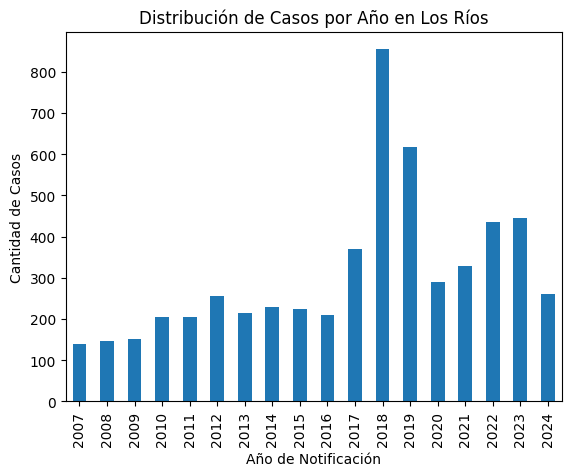

In [12]:
# Present the result as a bar chart (use matplotlib or pandas’ built-in .plot(kind="bar")
import matplotlib.pyplot as plt #importamos matplotlib para graficar
eno_lr["anho_notificacion"].value_counts().sort_index().plot(kind="bar") #graficamos la distribución de casos por año de notificación en Los Ríos
plt.xlabel("Año de Notificación") #etiqueta del eje x
plt.ylabel("Cantidad de Casos") #etiqueta del eje y
plt.title("Distribución de Casos por Año en Los Ríos") #título del gráfico
plt.show() #mostramos el gráfico

### 2.4. Top 5 enfermedades — Los Ríos

Se ve el top 5 de enfermedades en Los Ríos según ENO, el cual es el siguiente:

In [13]:
eno_lr["ENO"].value_counts().head(5) #top 5 enfermedades en Los Ríos según ENO

ENO
Sifilis                        1456
Parotiditis                    1377
VIH                             827
Infección gonocócica            598
Hidatidosis (Equinococosis)     388
Name: count, dtype: int64

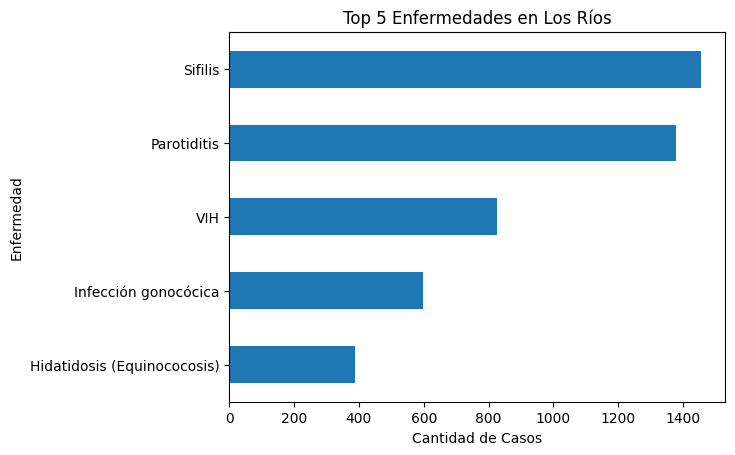

In [14]:
# Present the result as a horizontal bar chart.
eno_lr["ENO"].value_counts().head(5).sort_values().plot(kind="barh") #graficamos el top 5 de enfermedades en Los Ríos como gráfico de barras horizontal
plt.xlabel("Cantidad de Casos") #etiqueta del eje x
plt.ylabel("Enfermedad") #etiqueta del eje y
plt.title("Top 5 Enfermedades en Los Ríos") #título del gráfico
plt.show() #mostramos el gráfico

### 2.5. Distribución de nacionalidades en Los Ríos por ENO

Ahora se muestra la distribución de nacionalidades en Los Ríos según los datos de ENO. Se observa que la mayoría de los casos corresponden a personas de nacionalidad chilena, con un total de 2.818 casos. Sin embargo, también hay una cantidad significativa de casos con nacionalidad desconocida, con un total de 2.818 casos. Además, se registran casos de personas con nacionalidad extranjera, aunque en menor cantidad (175) en comparación con los casos chilenos y desconocidos.

In [15]:
#Show the distribution of nacionalidad in your region’s ENO data using .value_counts(). Note: you will likely see a "Desconocido" (unknown) category — report it, but do not drop it silently
eno_lr["nacionalidad"].value_counts() #distribución de nacionalidades en Los Ríos según ENO
# Encontramos 2.818 casos desconocidos, por lo que no podemos determinar su nacionalidad. Esto representa una parte significativa de los casos, por lo que es importante reportar esta categoría sin eliminarla, ya que podría afectar el análisis de la distribución de nacionalidades en la región.

nacionalidad
Desconocido    2818
Chile          2588
Extranjero      175
Name: count, dtype: int64

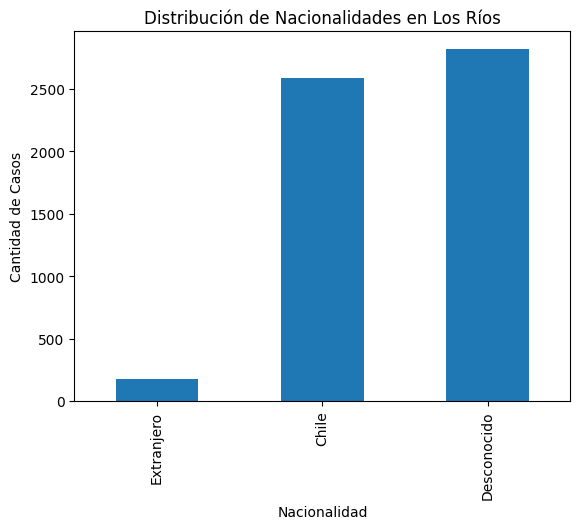

In [16]:
# Grafico la distribución de nacionalidades, incluyendo la categoría "Desconocido"
eno_lr["nacionalidad"].value_counts().sort_values().plot(kind="bar") #graficamos la distribución de nacionalidades en Los Ríos
plt.xlabel("Nacionalidad") #etiqueta del eje x
plt.ylabel("Cantidad de Casos") #etiqueta del eje y
plt.title("Distribución de Nacionalidades en Los Ríos") #título del gráfico
plt.show() #mostramos el gráfico

---
## Parte 3: GRD - Grupos Relacionados de Diagnóstico

In [17]:
import zipfile
import pandas as pd
cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
"FECHA_INGRESO", "FECHAALTA",
"IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(f, sep="|", usecols=cols,
        low_memory=False, encoding='latin1')
    print(f"Total discharges: {len(grd):,}")

Total discharges: 1,085,813


#### 3.2. Filtrar GRD a Los Ríos

In [18]:
#In GRD there is no region column. Instead, COMUNA contains the commune name in uppercase (e.g., "IQUIQUE"). You need to know which comunas belong to your region and filter with .isin():

my_comunas = ["CORRAL", "LANCO", "LOS LAGOS", "MAFIL", "MARIQUINA", "PAILLACO", "VALDIVIA", "PANGUIPULLI", "FUTRONO", "LAGO RANCO", "RIO BUENO", "LA UNION"] # comunas de la Región de Los Ríos (en mayúsculas)
grd_region = grd[grd["COMUNA"].isin(my_comunas)] #filtramos el GRD para quedarnos solo con las filas donde la comuna esté en la lista de comunas de nuestra región
print(f"Discharges in my region: {len(grd_region):,}") #cantidad de filas en el DataFrame del GRD filtrado por nuestra región

Discharges in my region: 20,795


### 3.3. Unir con CIE-10

In [19]:
#The DIAGNOSTICO1 column contains ICD-10 codes (e.g., "J18.9"). To get human-readable names, join with the lookup table:

cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10") #leemos el archivo excel que contiene la tabla de códigos CIE-10
grd_region = grd_region.merge( #hacemos un merge entre el GRD filtrado por región y la tabla de CIE-10 para obtener las descripciones de los diagnósticos
    cie10[["Código", "Descripción", "Capítulo"]], #seleccionamos solo las columnas relevantes de la tabla de CIE-10
    left_on="DIAGNOSTICO1", #hacemos el merge usando la columna DIAGNOSTICO1 del GRD como clave
    right_on="Código", #hacemos el merge usando la columna Código de la tabla de CIE-10 como clave
    how="left") #usamos un merge left para mantener todas las filas del GRD, incluso si no hay una coincidencia en la tabla de CIE-10
print(grd_region[["DIAGNOSTICO1", "Descripción"]].head()) #mostramos las primeras filas de las columnas DIAGNOSTICO1 y Descripción para verificar que el merge se hizo correctamente

  DIAGNOSTICO1                                        Descripción
0       S72.00              Fractura del cuello de fémur, cerrada
1        Z45.0          Asistencia y ajuste de marcapaso cardíaco
2        I63.1  Infarto cerebral debido a embolia de arterias ...
3        N84.0                        Pólipo del cuerpo del útero
4        K80.2     Cálculo de la vesícula biliar sin colecistitis


### 3.4. Top 5 diagnósticos — Los Ríos

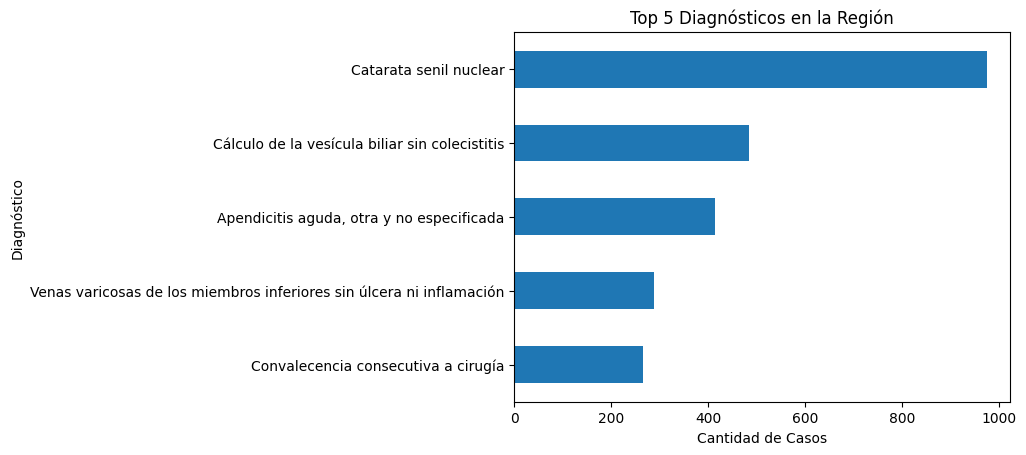

In [20]:
# Show the 5 most common diagnoses (by Descripción) in your region:
grd_region["Descripción"].value_counts().head(5)
# Present the result as a horizontal bar chart.
grd_region["Descripción"].value_counts().head(5).sort_values().plot(kind="barh") #graficamos el top 5 de diagnósticos en la región como gráfico de barras horizontal
plt.xlabel("Cantidad de Casos") #etiqueta del eje x
plt.ylabel("Diagnóstico") #etiqueta del eje y
plt.title("Top 5 Diagnósticos en la Región") #título del gráfico
plt.show() #mostramos el gráfico